<a href="https://colab.research.google.com/github/IvaroEkel/Probabilistic-Machine-Learning_lecture-PROJECTS/blob/main/TEMPLATE_Probabilistic_Machine_Learning_Project_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilistic Machine Learning - Project Report

**Course:** Probabilistic Machine Learning (SoSe 2025)
**Lecturer:** Alvaro Dias Ruelas 
**Student(s) Name(s):**  Arne Steffensen
**GitHub Username(s):**  Pinkcamouflage
**Date:**  15.08.2025
**PROJECT-ID:** 11-1SAXXXX_mobile_networks

---


## 1. Introduction ##
Accelerating mobile networks data transfers has been the primary objective for all telecommunicaion companies since their establishment. In this project the answer to the question of network quality depending on the location of the receiver is being answered based on a limited dataset around the airport Leipzig-Halle. This is to be achieved using probabilistic machine learning techniques. In visualizing the data during the exploration phase of the project as well as the evaluation an application of the HTWK RadioLab is being used. I am a part of the development team for this particular application and have participated partially or completely in the features used here later on.

The local quality of the mobile network can best be described by the three available features **RSRP**, **NR Scheduled PUSCH Thp in MBit/s** and **NR Avg PUSCH MCS** that are present in the dataset. To achieve a complete view of the situation in a particular location additional metrics have to be taken into account. These include the signal to interference and noise ratio and others. However, these metrics are not present in the given dataset. Therefore, the overall quality can only be estimated using these three features. **RSRP** is the most interesting metric in comparison to the **NR Scheduled PUSCH Thp in MBit/s** and **NR Avg PUSCH MCS** since the latter ones depend more on the receiving device used and can not be influenced by the company maintaining the cellular network. This project is therefore limited to only predict the downlink quality of the network. To achieve this, values of all given features have to be inspected.

The dataset includes the following parameters:

- **Timestamp**: Timestamp when the measurement was made  
- **Latitude**: Latitude coordinate where the measurement was made  ✅
- **Longitude**: Longitude coordinate where the measurement was made  ✅
- **NR PCI**: The Physical Cell Identifier of the particular base station  ✅
- **NR Serving SSB Index**: Index of the Synchronization Signal Block 
- **NR SS-RSRP in dBm**: Reference Signal Received Power  ✅
- **NR Scheduled PUSCH Thp in MBit/s**: Data rate of the uplink 
- **NR Avg Num PUSCH RB**: Average number of Ressource Blocks allocated for uplink 
- **NR Avg PUSCH MCS**: Average Modulation and Coding Scheme used for the uplink
- **NR Distance in meters**: Distance from the base station to the device  ✅
- **NR Direction in degrees**: Azimuth angle from the base station to the device
- **NR Direction Delta in degrees**: Delta angle between of the movement of the user and the cell
- **Label**: irrelevant

In the following, the suitability of each parameter is being examined to reduce the feature realm to only relevant and meaningful ones. Before even looking at distributions, some features can already be ruled out for further usage due to their characteristics visible to the observer. **Label** only has a constant value containing the name of the measurement campaign the measured points are part of. Then there are features that are difficult to evaluate later on. I do not have access to all the cell tower data and their respective configurations. This makes it very hard to evaluate the parameters **NR Direction in degrees** as well as **NR Direction Delta in degrees**. Furthermore, evaluating the parameter **NR Serving SSB Index** is also difficult due to issues creating an artificial dataset with meaningful values. Additionally, only the downlink side  In order to set these three parameters for an evaluation, cell tower configurations are needed. With these limitations in mind the features used in further analysis shrinks to only the highlighted features by the checkmark (✅).

On the other hand most of the other parameters are of high importance. For example **PCI** is a very important parameter since it provides the identifier of the base station the signal came from. Without this context, the model may contribute the variations in **Distance** to **RSRP** to noise. This was found out later on. **Distance** is also a very important parameter because the signal power diminishes with increaing distance with:

$$
\frac{\lambda}{4*\pi*d^2}
$$

$\lambda$ being the wavelength and $d$ the distance. **Latitude** and **Longitude** implicitly encode environment features such as buildings and the presence of a line of sight path which heavily increases signal strength.

The area of the measurement only partially spans the surroundings of three cells. Therefore, it is expected that no real generalizations can be made even for regional unseen locations. Lastly, to give a brief overview over the situation, this is a picture of the measurement with **RSRP** being plotted using the later cleaned data for better clearance. The more yellow the data point is the higher is the **RSRP**

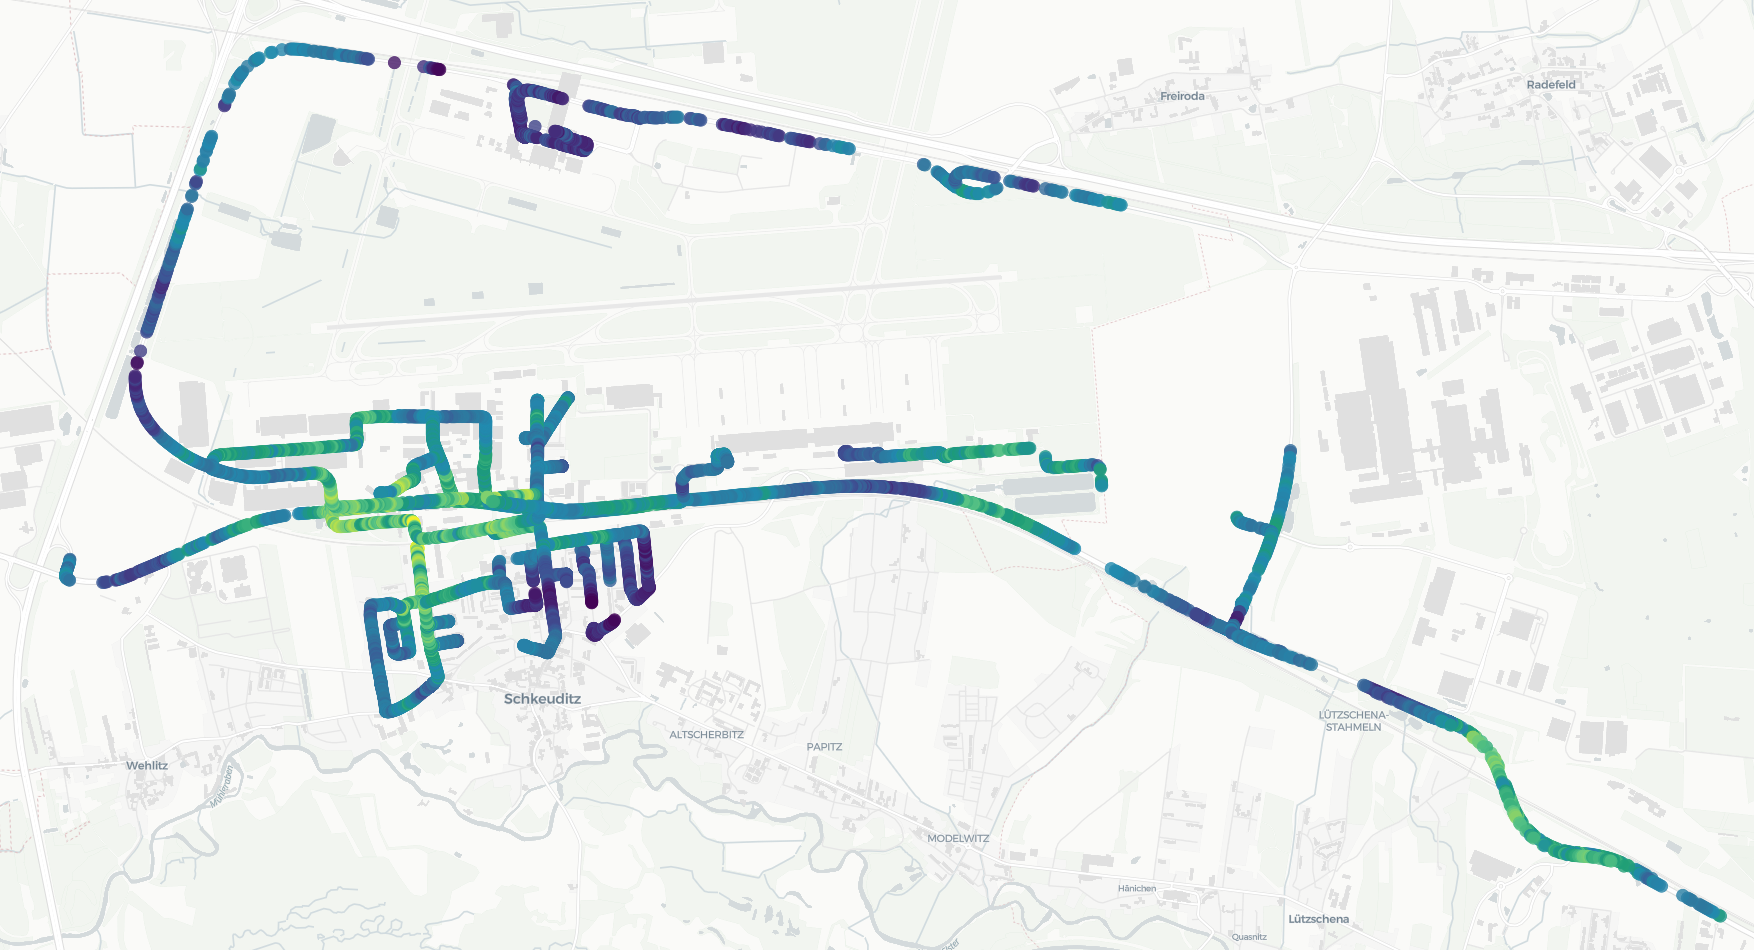


## 2. Data Loading and Exploration

- Code to load data
- Basic exploration (plots, statistics, missing data, etc.)



In [1]:
import pandas as pd

with open('data/measurement_data_export.csv', 'r') as file:
    df = pd.read_csv(file, sep=',', header=0)

df.describe()

,Latitude,Longitude,NR PCI,NR Serving SSB Index,NR SS-RSRP [dBm],NR Scheduled PUSCH Thp [MBit/s],NR Avg Num PUSCH RB,NR Avg PUSCH MCS,NR Distance [m],NR Direction [Â°],NR Direction Delta [Â°]
count,12741.000000,12741.000000,9882.000000,8800.000000,8798.000000,12735.000000,10892.000000,12741.000000,9814.000000,9814.000000,9814.000000
mean,51.403675,12.228570,305.075187,2.346477,-96.673005,13.346902,120.143775,12.242603,983.256394,37.058133,2.753670
std,0.008000,0.025369,219.499334,1.836374,10.445200,16.689372,84.221354,5.315915,650.927261,98.914357,34.550479
min,51.382744,12.184321,216.000000,0.000000,-122.100000,0.000000,4.000000,0.000000,21.408394,-179.967205,-179.360298
25%,51.398595,12.212584,216.000000,1.000000,-104.000000,0.063418,6.000000,9.000000,555.462562,-41.262990,-17.202280
50%,51.402922,12.220806,217.000000,2.000000,-97.300000,6.478483,162.000000,12.000000,772.895754,61.387887,3.164770
75%,51.405561,12.234831,218.000000,4.000000,-90.000000,22.701567,194.000000,16.000000,1239.087640,113.076877,22.798972
max,51.424994,12.313498,931.000000,6.000000,-58.100000,69.122776,217.000000,30.000000,4560.819024,179.955309,179.329890


The dataset includes 12741 measurement points. However, there are only 8798 points with values for one of the target features **RSRP**. When removing every row with at least one missing value as well as unrealistic values such as **RSRP**-values close to 0, of which there are a lot of, the total number of rows shrinks to 8751. This is not too bad of a decrease in comparison to the remaining data points and the reduction necessary by removing faulty **RSRP**-values. So a strategy to cope with these faulty values by transforming them or interpolating the values seem to be unnecessary. In the following, the correlation between the inverse of **Distance** and the target **RSRP** is being calculated. It is not necessary to compute this for **PCI**, **Latitude** and **Longitude**, where the expected dependence is obviously not linear.

In [2]:
rsrp = df['NR SS-RSRP [dBm]']
distance = df['NR Distance [m]']

inv_distance_sq = 1 / distance
print(f"Correlation between RSRP and 1/distance: {rsrp.corr(inv_distance_sq)}")

Correlation between RSRP and 1/distance: 0.39858915299600794


In [3]:
# Clean and save a copy of the data
df = df[df['NR SS-RSRP [dBm]'] < -10]
df = df.dropna(subset=['NR PCI', 'NR Serving SSB Index', 'NR SS-RSRP [dBm]', 'NR Distance [m]', 'NR Direction [Â°]', 'NR Direction Delta [Â°]'])

df.to_csv('data/cleaned_data.csv', index=False)

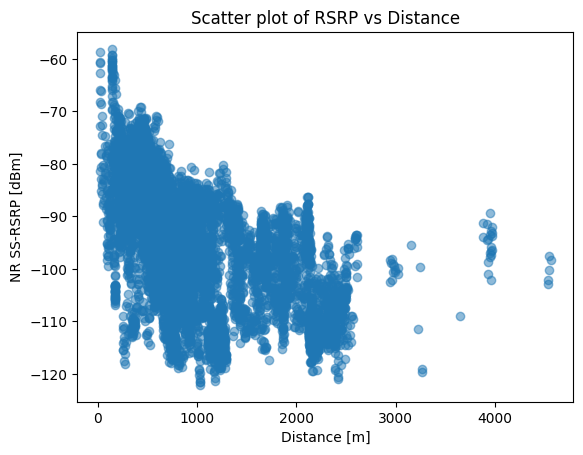

In [4]:
import matplotlib.pyplot as plt

plt.scatter(distance, rsrp, alpha=0.5)
plt.xlabel('Distance [m]')
plt.ylabel('NR SS-RSRP [dBm]')
plt.title('Scatter plot of RSRP vs Distance')
plt.show()

Using the scatter plot and the correlation between **Distance** and **RSRP** one can tell that there is a correlation, but not a linear one. This is expected as stated in the introduction. The highest values for **RSRP** occur under 1000 meters and there is no **RSRP** higher than $-85dBm$ further away than 2500 meters. However, the variance is very high, indicating that other features also are significant as well.

## 3. Data Preprocessing

The step of cleaning the data was done during the previous step. In order to effectively model the data, further normalization attempts are necessary. Experiments with machine learning models have shown that using unnormalized data results in low performing results. This is likely due to the varying variance of the predictors. **Latitude** and **Longitude** only vary in the first digit after the comma, whereas **distance** can reach values between $20$ and $4600$. All three of them are continous numeric features. **PCI** is numeric, but is a categoric metric in the integer range $0-1008$ and the target feature **RSRP** is numeric and continous again with values ranging from $-122$ to $-58$.

First, Min-Max-Normalzation is being applied and tested out for all features. This keeps the value ranges limited to $0-1$. Then, to reduce the hubness of the features as well, mean-normalization is applied for all continous features. **PCI** requires different treatment, since the present values are almost identical for a single cell tower containing three antenna elements that have very similar **PCI** values, eg. 216. 217, 218. These antenna elements are directed into opposite directions which leads to a different area of high **RSRP** for each element. The difference of 216 and 217 may be as significant as a difference between 216 and 926, which belongs to an entire different cell tower in the area. Therefore, embeddings are calculated for each present **PCI** using torches `nn.Embedding` function. This is done during the modelling and evaluation.




In [5]:
df.rename(columns={
    'Latitude': 'lat',
    'Longitude': 'lon',
    'NR PCI': 'pci',
    'NR SS-RSRP [dBm]': 'rsrp',
    'NR Distance [m]': 'distance',
}, inplace=True)

df = df[['lat', 'lon', 'distance', 'rsrp', 'pci']]

for col in df.columns:
    min_val = df[col].min()
    max_val = df[col].max()
    df[f"{col}_minmax"] = (df[col] - min_val) / (max_val - min_val)
    
for col in df.columns[:4]:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df[f"{col}_meannorm"] = (df[col] - mean_val) / std_val

df.to_csv('data/normalized_data.csv', index=False)
df.describe()

,lat,lon,distance,rsrp,pci,lat_minmax,lon_minmax,distance_minmax,rsrp_minmax,pci_minmax,lat_meannorm,lon_meannorm,distance_meannorm,rsrp_meannorm
count,8751.000000,8751.000000,8751.000000,8751.000000,8751.00000,8751.000000,8751.000000,8751.000000,8751.000000,8751.000000,8.751000e+03,8.751000e+03,8.751000e+03,8.751000e+03
mean,51.402957,12.225325,971.497058,-96.671660,292.67718,0.471321,0.321519,0.209298,0.397318,0.107996,-1.191367e-13,8.963995e-14,-1.299130e-16,-3.426455e-16
std,0.007265,0.023515,630.722851,10.460354,206.93957,0.174299,0.184387,0.138944,0.163443,0.291464,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,51.383310,12.184321,21.408394,-122.100000,216.00000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.704097e+00,-1.743717e+00,-1.506349e+00,-2.430925e+00
25%,51.398577,12.212023,556.504952,-104.000000,216.00000,0.366244,0.217216,0.117878,0.282812,0.000000,-6.028578e-01,-5.656720e-01,-6.579627e-01,-7.005823e-01
50%,51.402826,12.220339,772.526881,-97.300000,217.00000,0.468189,0.282423,0.165466,0.387500,0.001408,-1.796829e-02,-2.120287e-01,-3.154637e-01,-6.006867e-02
75%,51.405306,12.228229,1233.469290,-90.000000,218.00000,0.527684,0.344286,0.267008,0.501563,0.002817,3.233721e-01,1.234773e-01,4.153524e-01,6.378044e-01
max,51.424994,12.311853,4560.819024,-58.100000,926.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.033174e+00,3.679663e+00,5.690807e+00,3.687414e+00


## 4. Probabilistic Modeling Approach

First, a conventional model from the frequentist view is being trained. After that, a model from the bayesian perspective is going to be created. The models need to input a vector of $X \in \mathbb{R}^{n \times 4}$ assembling **Latitude**, **Longitude**, **Distance** and **PCI**
and want to predict the scalar **RSRP** values. The creation of the conventional model is not the focus. In creating the bayesian model, a Bayesian Neural Network (BNN) is being created. This fits the present problem of **RSRP** prediction due to the sparsity and varying measurements in areas. Additonally, not all features are known to the model which makes predicting the uncertainty in the given prediction of high value. The conventional model is expected to provide a predicted number regardless of its confidence and there is no practical way of knowing how confident the model really is. In case prior knowledge is known, this can be encoded into the prior distribution to help with the training process. However, this is not applicable here, since I do not have this knowledge.

There are multiple sources of uncertainty in this dataset.

 - **Aleatoric uncertainty**: This comes from measuring varying values on the same position. Reasons for this can be moving obsticles like buses crossing the line of site path or changing weather effects. These environmental influences lead to higher uncertainty in areas with high measurement point density.
 - **Epistemic uncertainty**: This comes from missing data in terms of area coverage as well as not included features as predictors. In this case there are sparse areas with little to no data especially in the north east. Additionally, some other features have been eliminated due to the diffculty in evaluating them or were not included in the dataset. An example would be surrounding buildings.

The BNN consists of two models. One to predict the mean value for **RSRP** and the other to estimate the uncertainty heteroscedastically. In the following, the mathematical definition and its operations are layed out.

### Mathematical Bayesian Formulation

Let

$$
\mathcal{D} = \left\{ \left( \mathbf{x}_i, y_i \right) \right\}_{i=1}^N
$$
 
be the dataset, where $x_i \in \mathbb{R}^4$ and $y_i$ is the observed (normalized) RSRP.  The likelihood is modelled as heteroscedastic Gaussian noise:

$$y_i \sim \mathcal{N}(\mu_i, \sigma_i^2)$$

where

$$\mu_i = f_\mu(x_i; \theta_\mu), \quad \sigma_i = \exp(f_\sigma(x_i; \theta_\sigma)) + \epsilon$$
with $\epsilon = 10^{-6}$ for numerical stability.

Here:

 - $f_\mu$ is the mean-prediction network
 - $f_\sigma$ is the noise-prediction network,
 - $\theta_\mu$ and $\theta_\sigma$ are their respective parameters.

#### Priors
Independent Gaussian priors are placed on all weights and biases:

$$
\theta_\mu \sim \mathcal{N}(0, A_\text{prior\_scale}^2), \quad \theta_\sigma \sim \mathcal{N}(0, \sigma_\text{prior\_scale}^2)
$$

where $A_\text{prior\_scale}$ is typically larger to allow more flexibility in the mean network, and $\sigma_\text{prior\_scale}$ is tighter to stabilize noise prediction.

#### Posterior Inference
The joint posterior over both parameter sets is:

$$p(\theta_\mu, \theta_\sigma \mid \mathcal{D}) \propto p(\mathcal{D} \mid \theta_\mu, \theta_\sigma)\, p(\theta_\mu)\, p(\theta_\sigma)$$

Because this distribution is intractable, mean-field variational inference is used to approximate it with:

$$𝑞(\theta_\mu, \theta_\sigma) = \prod_j \mathcal{N}(\theta_{\mu, j} \mid m_{\mu, j}, s_{\mu, j}^2) \cdot \prod_k \mathcal{N}(\theta_{\sigma, k} \mid m_{\sigma, k}, s_{\sigma, k}^2)$$
where $m$ and $s$ are the learnable variational parameters. The approximation is optimized by minimizing the KL-divergence between $q$ and the true posterior, implemented via the scaled ELBO objective in Pyro.

#### Predictive Distribution
For a new input $𝑥^*$, the predictive distribution is:

$$
p(y^* \mid x^*, \mathcal{D}) = \iint p(y^* \mid x^*, \theta_\mu, \theta_\sigma)\, p(\theta_\mu, \theta_\sigma \mid \mathcal{D})\, d\theta_\mu\, d\theta_\sigma
$$

In practice, this is approximated via Monte Carlo sampling:

Sample parameter sets $(\theta_\mu, \theta_\sigma)^{(t)} \sim q(\theta_\mu, \theta_\sigma)$.

Compute $\mu^{(t)}, \sigma^{(t)}$ for $x^*$.

Aggregate predictions to estimate:

- Predictive mean (central tendency),
- Epistemic uncertainty (spread of $\mu^{(t)}$ across samples),
- Aleatoric uncertainty (average predicted $\sigma^{(t)}$).


## 5. Model Training and Evaluation

The models are trained on a consumer grade desktop computer. For the conventional model `pytorch`'s cuda functionality is used to train it on the GPU, for the BNN on the other hand, using the GPU proved not to accellerate the process so the computations stayed on the CPU. The conventional model was trained for 30000 epochs and the one with the lowest test loss was ultimately chosen for further evaluations. The BNN model was trained for 20000 steps and the last 20000th was chosen for further evaluation. This was due to the fact that the losses (mean/std) did not fluctuate a lot anymore over the last steps. 

The models are being evaluated using similar functions to generate synthetic data within the bounding box of the minimum and maximum values for **Latitude** and **Longitude**. Then, for a small set of known base stations and their positions and **PCI** codes, input matrices are generated, normalizations applied and fed into the networks. The output is then denormalized and plotted using `matplotlib` to get an estimation of the predicted values. This leads to multiple images that only have a chance to include reasonable data within the small radius the base station operates. In order to compute an estimate for the region, those pictures need to be combined into a single image where only the highest local value remain since devices would always chose the best cell tower for communication. These pictures are also generated for standard deviation returned by the BNN.

## 6. Results

### Conventional model results

The results of the conventional model using ~100000 parameters in four layers are as expected only accurate in the limited space where the cell is active. However, it is difficult to assess the situation due to the extreme deviations from observable **RSRP** values in the field. The predicted values exceed zero in some areas as well as negative 210. This was expected since the test loss function showed little stability and significantly higher values than would be expected for an accurate prediction:

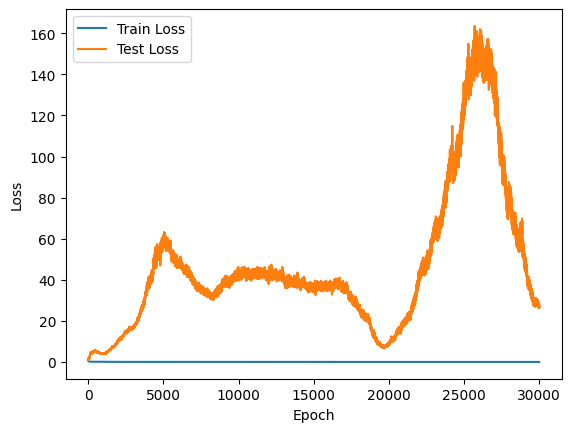

For the evaluation, one of the ealier models was chosen. Having only a test loss of $1.81$ what is still high compared to the $0.02$ for the training loss at the end. Here is a collection of generated images for different **PCI** cells:

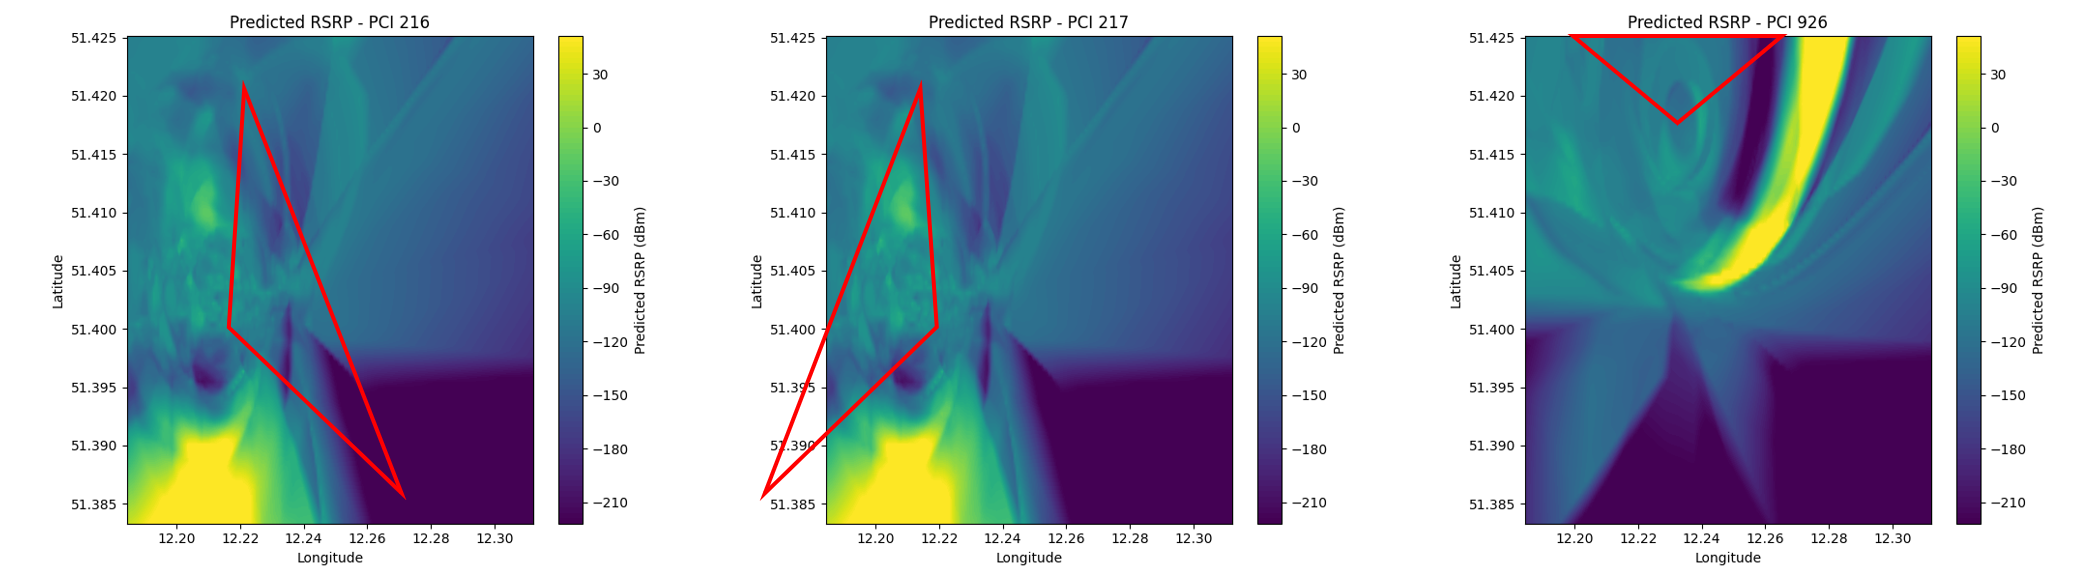

The red frames represent the cone where the antenna element is directed in. Notably, the values are clipped above $50$ and below $-220$. Otherwise, an assessment of the situation in the interesting areas would not have been possible.

### BNN model results

The results of the BNN model using the entire dataset as training data achieved a training loss of $~8000$ and an average sigma of $0.5$ which is calculated on the transformed data. When transformed back to the real world scenario, the standard deviation increases. Here are the losses over time:

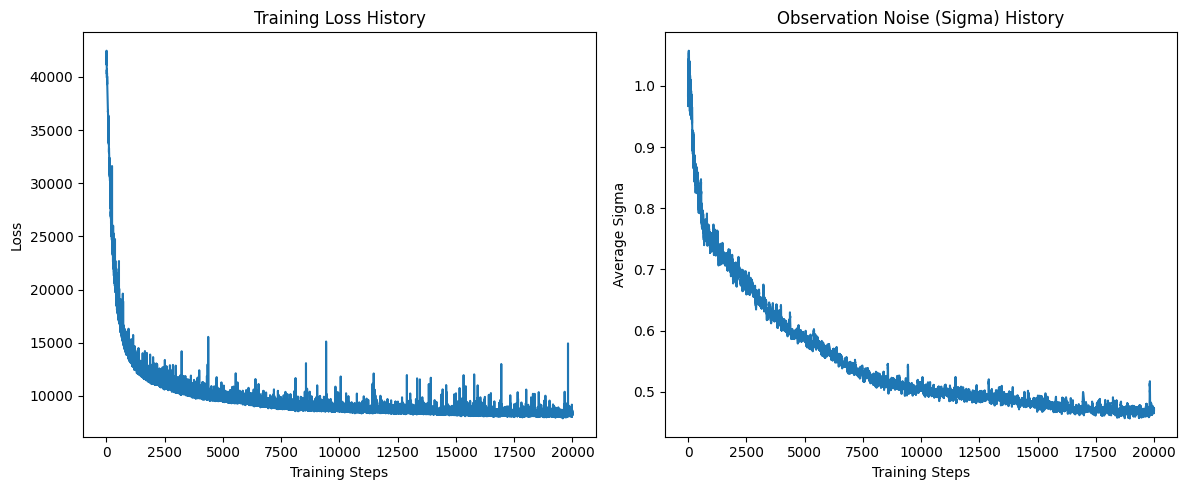

The same synthetic data is also used for evaluation here. The predicted values lay in for **RSRP** common ranges between $-70$ and $-140$. Which is a good sign as shown in the picture below for **PCI** 216.

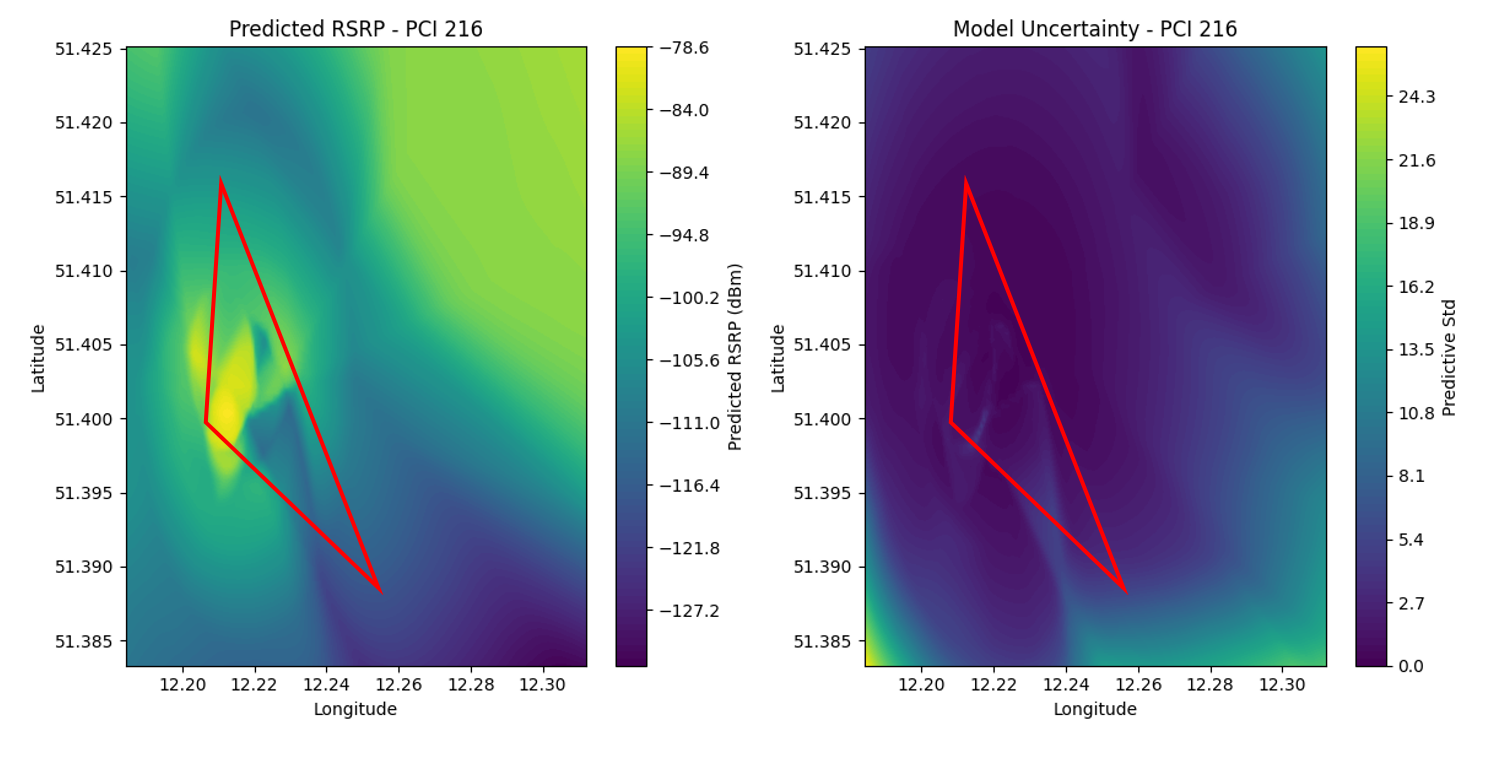

It is visible that the values are high in the proximity of the cell. The standard deviation also increases with distance from the base station peaking at $25$ where the model shows basically no confidence into the predicted value.

Summarizing the results of the BNN, in the following plots the maximum possible value at each location is shown using the limited cell tower information available as well as the input data. Unfortunately, the predicted values and the original data do not use the same color ranges. This makes the assessment difficult. When inspecting in detail, the values align. The plot can still be used for qualitative analysis on changes in values over the area. The last plot shows the predicted standard deviation for the area in comparison to the mean.

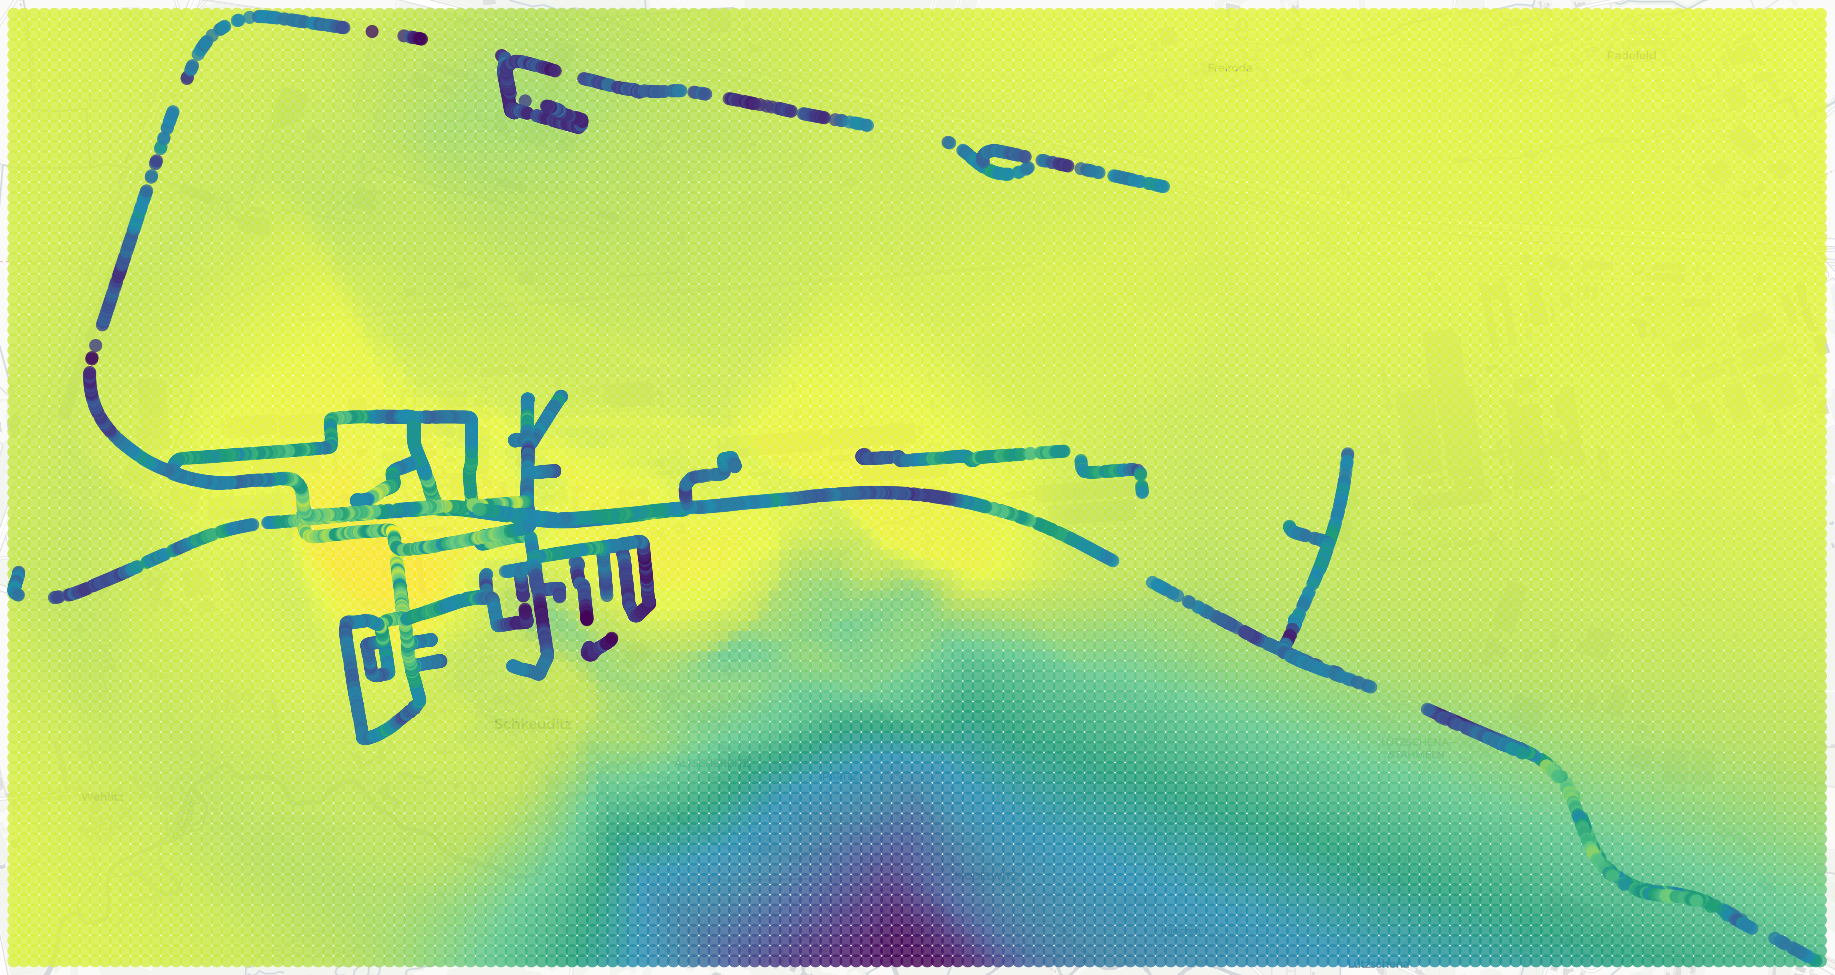

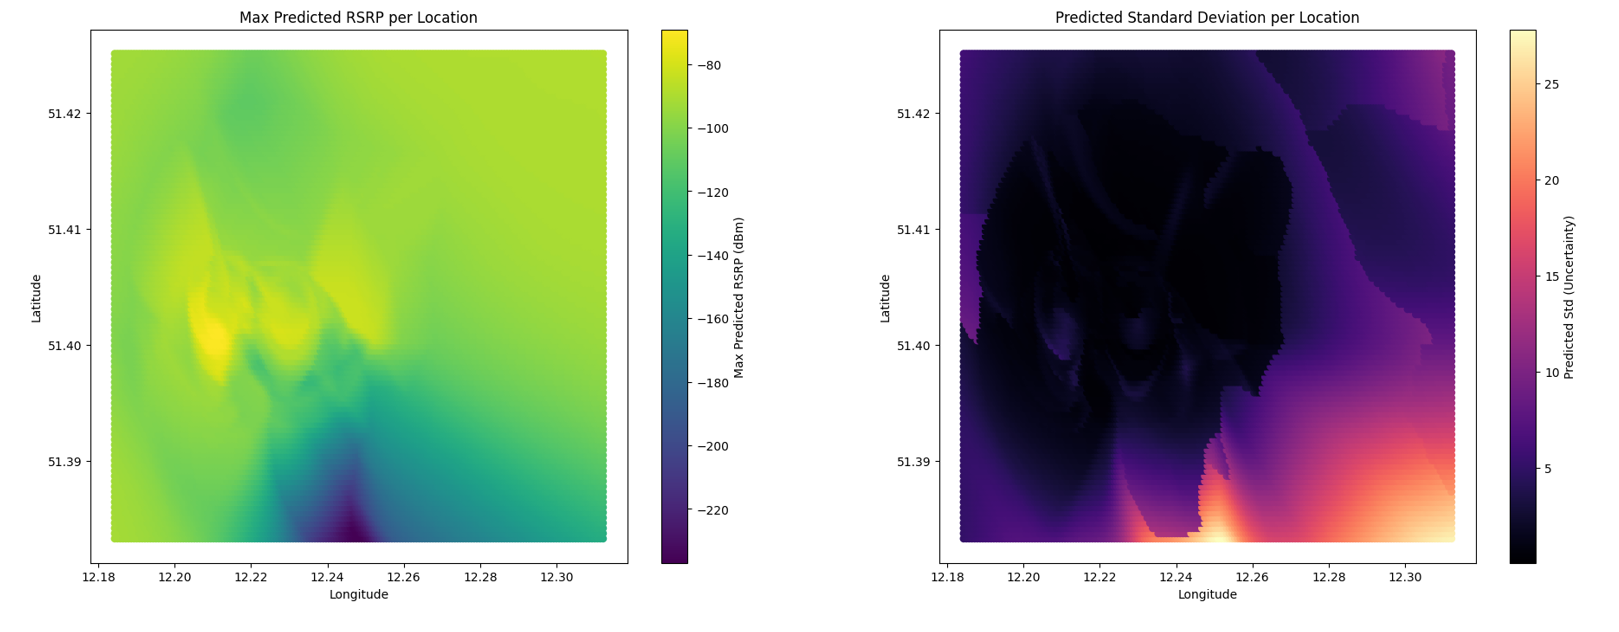


## 7. Discussion

Analyzing the results, one can come to the conclusion that the results of the conventional model are of no use. The complete deviation from expected value ranges for **RSRP**, especially the one above zero, makes the prediction unuseable. That is why no combining plot of the pictures was possible because the baseless increase when increasing the distance from the cell tower makes selecting the correct data point impossible. On the other hand, the results of the BNN were promising. The model predicted the highest values in proximity of the cell towers, allthough the values are a bit lower compared to the measured ones. This may be due to the aleatoric uncertainty mentioned earlier occuring mainly in areas with high measurement density. In the combined plot of the uncertainty sudden increases in uncertainty can be detected in this areas too. These are small but may still make values of $-58dBm$ achievable. The higher the distance grows between the location and the cell towers, the uncertainty increases to the point where no real estimation can be given. This is especially the case in the southeast and north east of the observed area. In evaluation, a small set of base stations were used of which all lied in the west and center of the area. Which lead to the expected increase of uncertainty in the east. Additionally, the data density is significantly lower in the east, increasing epistemic uncertainty. This form of uncertainty seem to be more dominant. 

However, the bayesian model did not capture the linkage between distance and **RSRP** correctly. The reduction in predicted **RSRP** flattens out after a certain distance with one exception at roughly $3000$ meters. As shown earlier during the exploration phase of the project the data did not include lots of data exceeding distances above $3000$ meters making it hard for the model to predict a further decrease. Another limitation imposed by insufficient data is the absence of area filling measurements. Most data points form chains and do not make it easy for the model to interpolate. In the area, where there are the most measurement points, the accuracy is the highest but when the space between points becomes too large, predictions are completely off. An example would be the low values on the runways, where it is difficult to measure for obvious reasons. Additionally, some **PCI** values are very underrepresented in the dataset making them unsusable for evaluation.

Limitations are also introduced by the evaluation process. Since the known cell towers are in the west and center and are few, the predictions in the east are difficult to evaluate. When running the training multiple times, there are deviations in the evaluation results.

When intending to achieve a sophisticated result, one have to increase the dataset first as this is by far the greatest limitation in this case. The following data extentions would increase the quality of the results:

 - **Area size increase**: The area would have to be increased making for a better generalization and including more complete antenna element cones.
 - **More features**: One feature that would have been useful is data of the surrounding buildings. This would have provided more direct information about the environment. Other features such as height/elevation and ray tracer data could also improve the performance.
 - **Just more data points**: This would have limited the epistemic uncertainty reducing the largest factor of uncertainty in this case.

When this data is available one would also partition the training data into training, test and validation datasets for evaluating generalization as it is the standard procedure for machine learning applications. If necessary the model size could also be increased.

## 8. Conclusion

During the project phases a meaningful BNN was trained providing **RSRP** and uncertainty estimates. The generation of a useful frequentist model failed. In conclusion, the comparison between the conventional model and the BNN demonstrates the advantage of the latter in capturing the spatial patterns of RSRP within the observed area. While the conventional model produced results far outside realistic value ranges the Bayesian approach yielded predictions that aligned more closely with the expected signal distribution. The BNN was able to reflect higher values in proximity to cell towers and to provide uncertainty estimates that correlated with regions of dense measurements and areas lacking coverage. Nevertheless, the model’s inability to fully capture the relationship between distance and RSRP, especially beyond 3000 meters, highlights the limitations imposed by the dataset. Sparse measurements, underrepresented PCI values, and the absence of area-filling data hindered both accuracy and generalization, with epistemic uncertainty dominating in regions far from the limited set of known base stations. Furthermore, the lack of features describing environmental factors, such as building structures or elevation, constrained the model’s capacity to account for local signal variations. Addressing these shortcomings through a larger, more representative dataset, the inclusion of additional relevant features, and a proper training–validation–test split would enable a more robust evaluation and likely improve predictive performance. With these refinements, the BNN could provide not only more accurate **RSRP** estimates but also a well-calibrated measure of uncertainty, making it a valuable tool for network analysis and planning.

## 9. References

The dataset was provided by the HTWK RadioLab. Some pictures were taken from a development version of the "Radio Analysis and Visualization for Evaluation and Reporting" Tool in short RAVER. The following python libraries and their dependencies were used:

 - sklearn
 - pytorch
 - pyro-ppl
 - matplotlib
 - pandas
 - numpy
 - pyproj